# Jacobian normalization and its effect on PINN convergence - Results

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.optim.lr_scheduler import ExponentialLR
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.legend_handler import HandlerTuple
from scipy.sparse.linalg import eigsh

from scipy.integrate import solve_ivp

from sklearn.linear_model import HuberRegressor

from pinn import PINN
from alt_pinn import PINN2

In [2]:
plt.rcParams.update({
    "savefig.dpi": 200,
    "text.usetex": True,
    "font.family": "serif",
    "font.sans-serif": ["Computer Modern Sans Serif"],
    'text.latex.preamble': r'\usepackage{amsfonts}'})

## Constant parameters

In [3]:
C_list = np.logspace(0, 4, 20, endpoint=True)

num_coloc = 1000
x_co_np = np.exp(np.linspace(-15.0, 0.0, num_coloc))
x_co = torch.tensor(x_co_np, dtype=torch.float32).view(-1, 1).requires_grad_(True)

## FEM functions and parameters

In [4]:
# Parameters
x_span = (np.exp(-15), 1)  # Interval of integration
x_eval = np.exp(np.linspace(-15, 0, 1000))  # Points for evaluation

# Define the ODE: dy/dx = -C*y
def dydx_toy1(x, y, C):
    return -C * y

def dydx_toy2(x, y, C):
    return -C * y**2

def dydx_toy3(x, y, C):
    return C * (np.sin(x) - y)

## Loss function

In [5]:
def make_loss(C, normalize_jac, toy_number):
    def pinn_loss(self, x):
            
        x = x.clone().detach().requires_grad_(True)

        # Forward pass
        y = self.forward(x)

        # dy/dx via autograd
        dy_dx = torch.autograd.grad(
            outputs=y,
            inputs=x,
            grad_outputs=torch.ones_like(y),
            create_graph=True,
            retain_graph=True
        )[0]

        lhs = dy_dx
        if toy_number == 1:
            rhs = - C * y
            jac = -C
            x0_loss = torch.square(y[0] - torch.exp(-C * x[0]))
        if toy_number == 2:
            rhs = - C * y**2
            jac = -2.0 * C * y
            x0_loss = torch.square(y[0] - 1.0 / (1.0 + C * x[0]))
        if toy_number == 3:
            rhs = C * (torch.sin(x) - y)
            jac = -C
            x0_loss = torch.square(y[0] - torch.exp(-C * x[0]))

        residual = (lhs - rhs)
        ode_loss = torch.mean(residual**2 / (1.0 + normalize_jac * jac**2))

        total_loss = ode_loss + x0_loss
        
        return ode_loss, x0_loss, total_loss
    return pinn_loss

## Plotting functions

In [6]:
# Font sizes and spacing
font_size  = 30     # Font size for tick labels and legend text
title_size = 32     # Font size for plot title
tick_pad   = 10     # Padding (points) between ticks and their labels

# X-axis limits (in log10 space in your plots)
xmin = -0.085       # Left x limit (e.g. log10(C)=0 -> C=1)
xmax = 4.085        # Right x limit (e.g. log10(C)=4.1 -> C≈1.26e4)

# Line and marker settings
col_unnorm = "blue"        # Unnormalized (vanilla) PINN
col_norm   = "magenta"     # Jacobian-normalized PINN

lw_fit = 3.2        # Line width for plotted lines (fits or connecting curves)
ms     = 12         # Scatter marker scale (you use s=ms**2, so area scales like ms^2)
mew    = 2.2        # Marker edge width (stroke thickness), also used for 'x' linewidth


In [7]:
def eigVSjac(toy_number, C_lst, eig_lst_norm, eig_lst_unnorm, eq_rhs, Legend = True):
    # Convert inputs to log10 space
    log_x = np.log10(C_lst)
    log_y_norm = np.log10(eig_lst_norm)
    log_y_unnorm = np.log10(eig_lst_unnorm)

    # Fit Huber regression to normalized data
    huber_norm = HuberRegressor()
    huber_norm.fit(log_x.reshape(-1, 1), log_y_norm)

    # Fit Huber regression to unnormalized data
    huber_unnorm = HuberRegressor()
    huber_unnorm.fit(log_x.reshape(-1, 1), log_y_unnorm)

    # Read off slopes and intercepts
    slope_norm = huber_norm.coef_[0]
    intercept_norm = huber_norm.intercept_
    slope_unnorm = huber_unnorm.coef_[0]
    intercept_unnorm = huber_unnorm.intercept_

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Axis styling
    plt.setp(ax.spines.values(), linewidth=1.50)
    ax.set_axisbelow(False)

    # Limits and labels
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0.0, 9.2)
    ax.set_xlabel(r"$\log_{10}C$", fontsize=font_size)
    ax.set_title(r"$\displaystyle \frac{dy}{dx} =$" + f"${eq_rhs}$", fontsize=title_size, pad=30)

    # Plot the fitted lines
    l_v, = ax.plot(np.linspace(*ax.get_xlim(), 200), slope_unnorm * np.linspace(*ax.get_xlim(), 200) + intercept_unnorm, color=col_unnorm, linestyle="--", linewidth=lw_fit, zorder=2)
    l_n, = ax.plot(np.linspace(*ax.get_xlim(), 200), slope_norm * np.linspace(*ax.get_xlim(), 200) + intercept_norm, color=col_norm, linestyle="--", linewidth=lw_fit, zorder=2)

    # Plot the data points
    s_v = ax.scatter(log_x, log_y_unnorm, marker="x", s=ms**2, c="black", linewidths=mew, zorder=2.1)
    s_n = ax.scatter(log_x, log_y_norm, marker=".", s=ms**2, facecolors="none", edgecolors="black", linewidths=mew, zorder=2.1)

    # Toy 1: left y-axis label; include legend entries for the scatter points
    if toy_number == 1:
        ax.set_ylabel(r"$\log_{10}\lambda_{\max}$", fontsize=font_size)
    # Toy 2: left y-axis label; scatter points without labels
    elif toy_number == 2:
        ax.set_ylabel(r"$\log_{10}\lambda_{\max}$", fontsize=font_size)
    # Toy 3: right y-axis label; scatter points without labels
    elif toy_number == 3:
        ax.set_ylabel(r"$\log_{10}\lambda_{\max}$", fontsize=font_size, rotation=270, labelpad=30)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

    # Legend styling
    if Legend:
        ax.legend([(s_v, l_v), (s_n, l_n)], [rf"$\lambda_{{\max}}^{{\mathrm{{fit}}}} \sim J^{{{slope_unnorm:.2f}}}$ (Vanilla)", rf"$\lambda_{{\max}}^{{\mathrm{{fit}}}} \sim J^{{{slope_norm:.2f}}}$ (Normalized)"], handler_map={tuple: HandlerTuple(ndivide=None, pad=0.2)}, fontsize=font_size, frameon=False, handlelength=2.3, handletextpad=0.6)
    else:
        ax.legend([rf"$\lambda_{{\max}}^{{\mathrm{{fit}}}} \sim J^{{{slope_unnorm:.2f}}}$ (Vanilla)", rf"$\lambda_{{\max}}^{{\mathrm{{fit}}}} \sim J^{{{slope_norm:.2f}}}$ (Normalized)"], handler_map={tuple: HandlerTuple(ndivide=None, pad=0.2)}, fontsize=font_size, frameon=False, handlelength=0.0, handletextpad=0.6)

    # Tick styling
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.tick_params(axis="both", which="major", direction="in", bottom=True, top=True, left=True, right=True, length=8, width=1.2, pad=tick_pad, labelsize=font_size)
    ax.tick_params(axis="both", which="minor", direction="in", bottom=True, top=True, left=True, right=True, length=4, width=1.2)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Save the figure
    fig.savefig(f"Toy{toy_number}-eigVSjac.png", bbox_inches="tight", dpi=500, pad_inches=0.01)

    # Show the plot
    plt.show()

In [8]:
def PINNvsFEM_diff(toy_number, C_lst, eq_rhs):
    msd_norm = []
    msd_unnorm = []
    
    for c in C_lst:
        if toy_number == 1:
            y0 = np.exp(-c * x_co_np[0])
            sol = solve_ivp(dydx_toy1, x_span, [y0], method='BDF', args=(c,), t_eval=x_eval)
        if toy_number == 2:
            y0 = 1.0 / (1.0 + c * x_co_np[0])
            sol = solve_ivp(dydx_toy2, x_span, [y0], method='BDF', args=(c,), t_eval=x_eval)
        if toy_number == 3:
            y0 = np.exp(-c * x_co_np[0])
            sol = solve_ivp(dydx_toy3, x_span, [y0], method='BDF', args=(c,), t_eval=x_eval)
            
        loss_fn = make_loss(c, True, toy_number)
        model = PINN(40, 4, 1, 8.0e-5, loss_fn)
    
        model.load_state_dict(torch.load('./dataToys/best-Toy' + str(toy_number) + '-normTrue-' + str(int(np.ceil(c))) + '.pt'))
        preds_norm = model.predict(x_co)
    
        model.load_state_dict(torch.load('./dataToys/best-Toy' + str(toy_number) + '-normFalse-' + str(int(np.ceil(c))) + '.pt'))
        preds_unnorm = model.predict(x_co)

        preds_norm = preds_norm.detach().numpy()
        preds_unnorm = preds_unnorm.detach().numpy()
    
        msd_norm.append(np.mean((preds_norm.flatten() - sol.y[0])**2))
        msd_unnorm.append(np.mean((preds_unnorm.flatten() - sol.y[0])**2))

    log_x = np.log10(C_lst)
    log_y_norm = np.log10(msd_norm)
    log_y_unnorm = np.log10(msd_unnorm)

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Axis styling
    plt.setp(ax.spines.values(), linewidth=1.50)
    ax.set_axisbelow(False)
    
    # Limits and labels
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-7.6, 0.2)
    ax.set_xlabel(r"$\log_{10}C$", fontsize=font_size)

    # Plot lines
    ax.plot(np.linspace(xmin, xmax, 300), np.interp(np.linspace(xmin, xmax, 300), log_x, log_y_unnorm), color=col_unnorm, linestyle=(0, (1, 1)), linewidth=lw_fit, zorder=2)
    ax.plot(np.linspace(xmin, xmax, 300), np.interp(np.linspace(xmin, xmax, 300), log_x, log_y_norm),   color=col_norm,   linestyle=(0, (1, 1)), linewidth=lw_fit, zorder=2)

    # Plot the data points
    ax.scatter(log_x, log_y_unnorm, marker="x", s=ms**2, c="black", linewidths=mew, zorder=2.1)
    ax.scatter(log_x, log_y_norm, marker=".", s=ms**2, facecolors="none", edgecolors="black", linewidths=mew, zorder=2.1)

    # Toy 1 & 2: left y-axis label
    if toy_number == 1 or toy_number == 2:
        ax.set_ylabel(r"$\log_{10}\overline{\varepsilon}$", fontsize=font_size)
    # Toy 3: right y-axis label
    elif toy_number == 3:
        ax.set_ylabel(r"$\log_{10}\overline{\varepsilon}$", fontsize=font_size, rotation=270, labelpad=30)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

    # Tick styling
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.tick_params(axis="both", which="major", direction="in", bottom=True, top=True, left=True, right=True, length=8, width=1.2, pad=tick_pad, labelsize=font_size)
    ax.tick_params(axis="both", which="minor", direction="in", bottom=True, top=True, left=True, right=True, length=4, width=1.2)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Save the figure
    fig.savefig(f"Toy{toy_number}-PINNvsFEM.png", bbox_inches="tight", dpi=500, pad_inches=0.01)

    # Show the plot
    plt.show()

In [9]:
def PINNvsFEM_fit(toy_number, C_lst, eq_rhs):
    for c in C_lst:
        if toy_number == 1:
            y0 = np.exp(-c * x_co_np[0])
            sol = solve_ivp(dydx_toy1, x_span, [y0], method='BDF', args=(c,), t_eval=x_eval)
        if toy_number == 2:
            y0 = 1.0 / (1.0 + c * x_co_np[0])
            sol = solve_ivp(dydx_toy2, x_span, [y0], method='BDF', args=(c,), t_eval=x_eval)
        if toy_number == 3:
            y0 = np.exp(-c * x_co_np[0])
            sol = solve_ivp(dydx_toy3, x_span, [y0], method='BDF', args=(c,), t_eval=x_eval)
            
        loss_fn = make_loss(c, True, toy_number)
        model = PINN(40, 4, 1, 8.0e-5, loss_fn)
    
        model.load_state_dict(torch.load('./dataToys/best-Toy' + str(toy_number) + '-normTrue-' + str(int(np.ceil(c))) + '.pt'))
        preds_norm = model.predict(x_co)
    
        model.load_state_dict(torch.load('./dataToys/best-Toy' + str(toy_number) + '-normFalse-' + str(int(np.ceil(c))) + '.pt'))
        preds_unnorm = model.predict(x_co)

        preds_norm = preds_norm.detach().numpy()
        preds_unnorm = preds_unnorm.detach().numpy()
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Axis styling
    plt.setp(ax.spines.values(), linewidth=1.50)
    ax.set_axisbelow(False)

    # Plot lines
    ax.plot(x_co_np, preds_norm, color=col_norm, linewidth=lw_fit, label="Normalized")
    ax.plot(x_co_np, preds_unnorm, color=col_unnorm, linewidth=lw_fit, label="Vanilla")
    ax.plot(x_co_np, sol.y[0], color="black", linestyle=":", linewidth=lw_fit, label="FEM")

    # Limits and labels
    ax.set_xlim(np.min(x_co_np), np.max(x_co_np))
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel(r"$x$", fontsize=font_size)
    ax.set_ylabel(r"$y$", fontsize=font_size)
    ax.set_title(r"$\displaystyle \frac{dy}{dx} =$" + f"${eq_rhs}$", fontsize=title_size, pad=25)

    # Scales
    ax.set_xscale("log")

    # Tick styling (same pattern as your other plots)
    ax.tick_params(axis="both", which="major", direction="in", bottom=True, top=True, left=True, right=True, length=8, width=1.2, pad=tick_pad, labelsize=font_size)
    ax.tick_params(axis="both", which="minor", direction="in", bottom=True, top=True, left=True, right=True, length=4, width=1.2)
    ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs="auto", numticks=10))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Legend
    ax.legend(fontsize=font_size, frameon=False, handlelength=1.5, markerscale=1.0)

    # Save and show
    fig.savefig(f"Toy{toy_number}-PINNvsFEM_fit.png", bbox_inches="tight", dpi=500, pad_inches=0.01)
    plt.show()

## A benchmark on the simplest class of stiff ODEs: $\frac{dy}{dx} = -Cy$

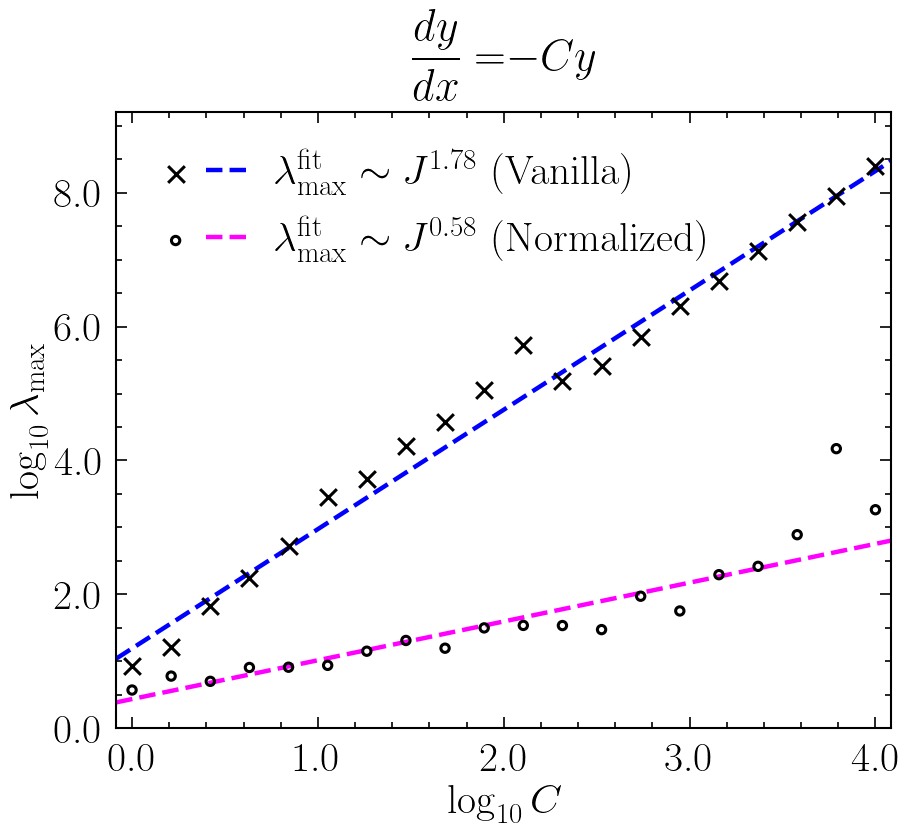

In [10]:
eig_norm = [3.73, 6.02, 5.03, 8.1, 8.17, 8.72, 14.17, 20.51, 15.71, 31.6, 34.42, 34.25, 29.79, 93.91, 56.58, 197.06, 262.37, 779.46, 15014.76, 1838.76]
eig_unnorm = [8.63, 16.43, 68.18, 175.28, 522.33, 2876.17, 5252.66, 16572.66, 37955.31, 111701.03, 528647.19, 153494.14, 259375.69, 700196.12, 2040236.38, 4850601.0, 13520665.0, 36586352.0, 90597576.0, 250497568.0]

eigVSjac(1, C_list, eig_norm, eig_unnorm, '-Cy')

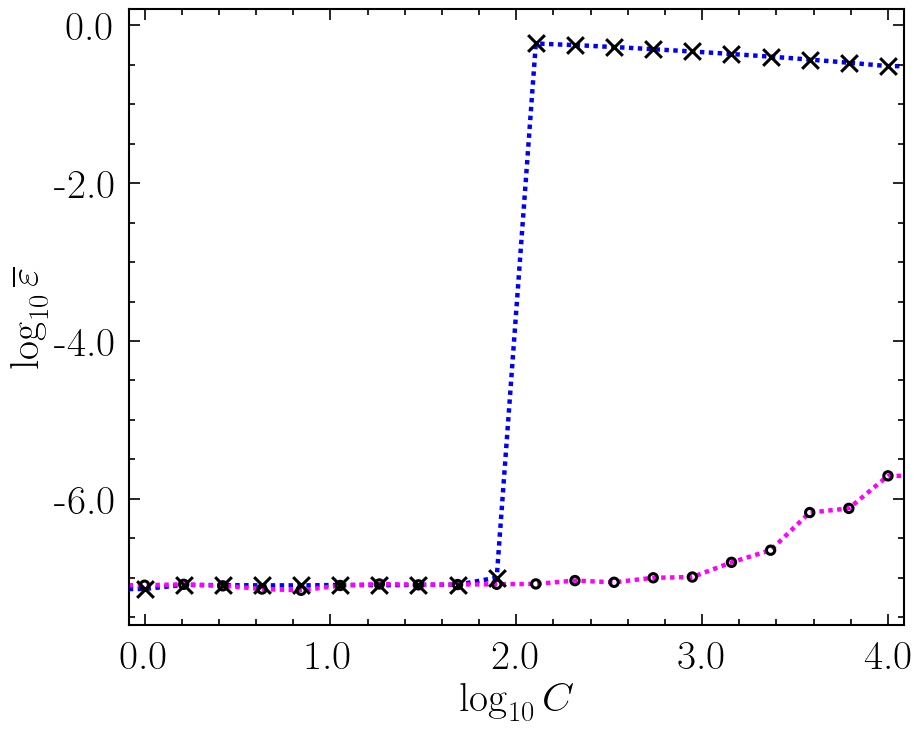

In [11]:
PINNvsFEM_diff(1, C_list, '-Cy')

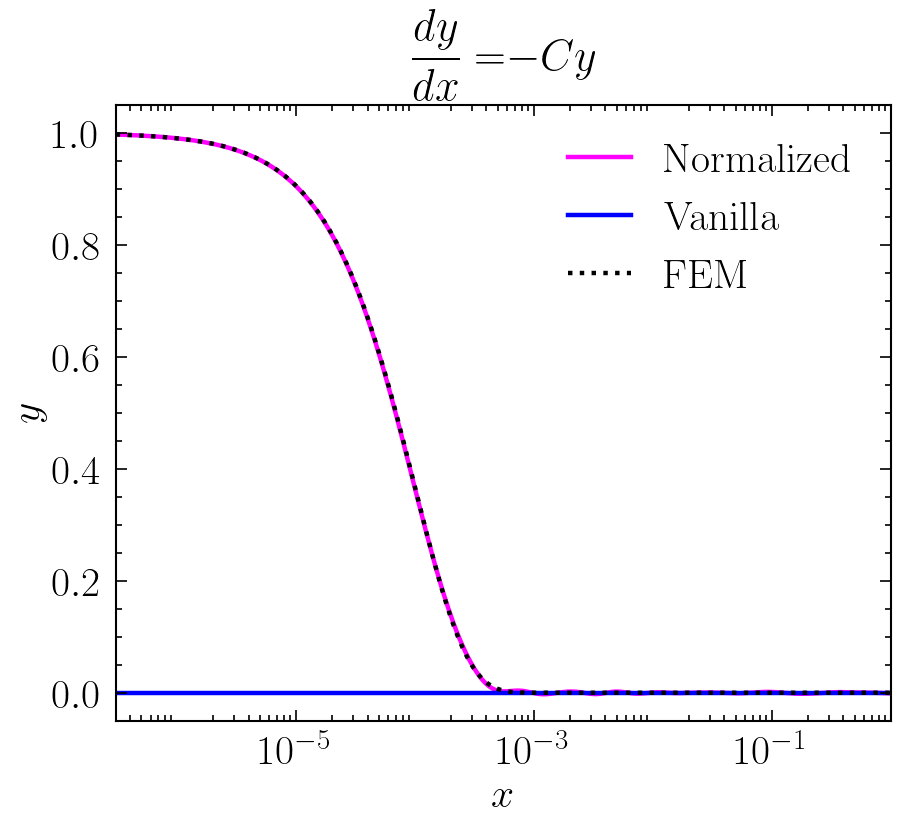

In [12]:
PINNvsFEM_fit(1, C_list, '-Cy')

## Benchmark on nonhomogeneous ODEs: $\frac{dy}{dx} = -Cy^2$

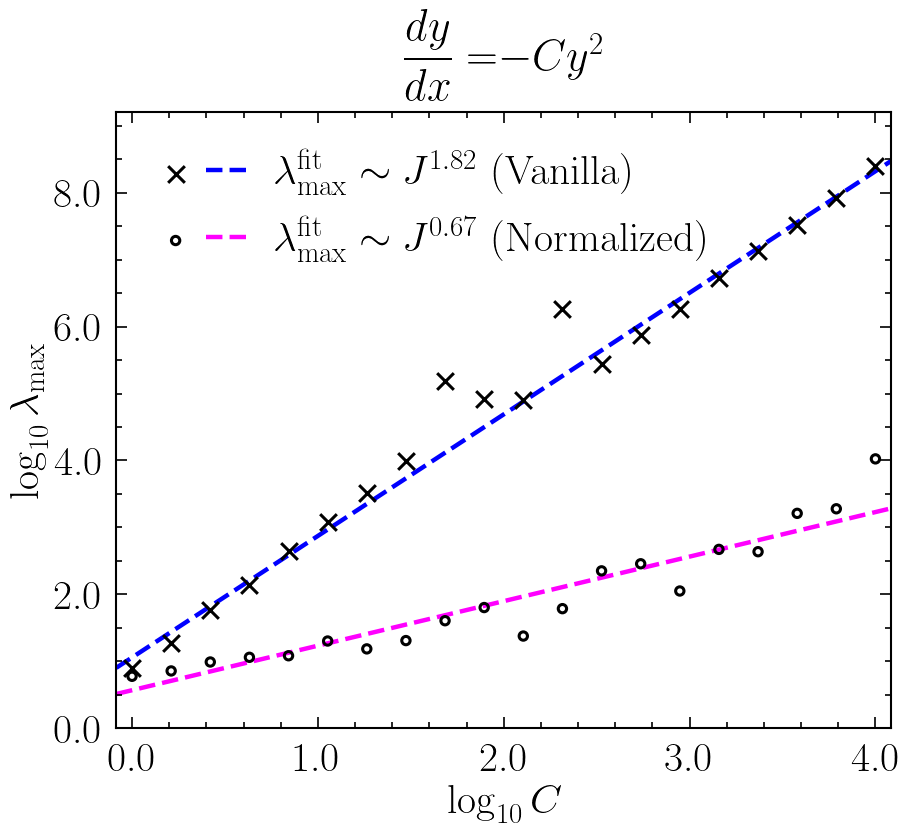

In [13]:
eig_norm = [5.98, 7.19, 9.78, 11.49, 12.12, 20.12, 15.35, 20.42, 40.43, 63.6, 23.87, 61.22, 224.58, 286.62, 112.39, 470.08, 434.07, 1622.87, 1899.34, 10566.02]
eig_unnnorm = [31.98, 74.28, 304.11, 926.48, 2732.98, 10907.1, 27986.73, 87158.84, 227698.14, 1062403.12, 2057864.25, 4538843.0, 18318900.0, 50778932.0, 18354440.0, 21351702.0, 6264970.5, 3846627.0, 5490498.0, 6859650.0]

eigVSjac(2, C_list, eig_norm, eig_unnorm, '-Cy^2')

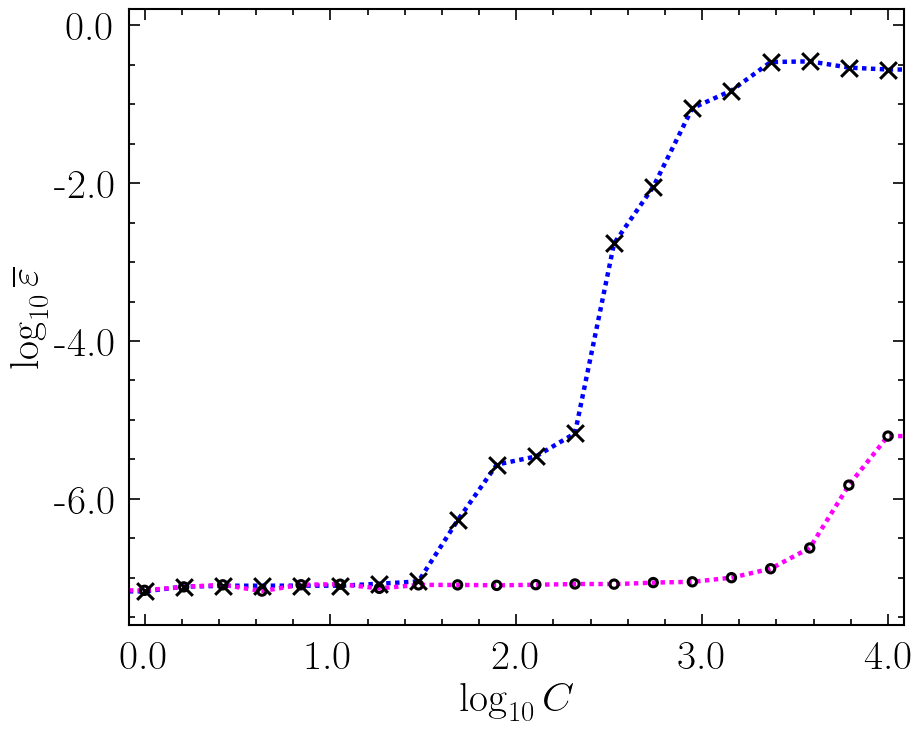

In [14]:
PINNvsFEM_diff(2, C_list, '-Cy^2')

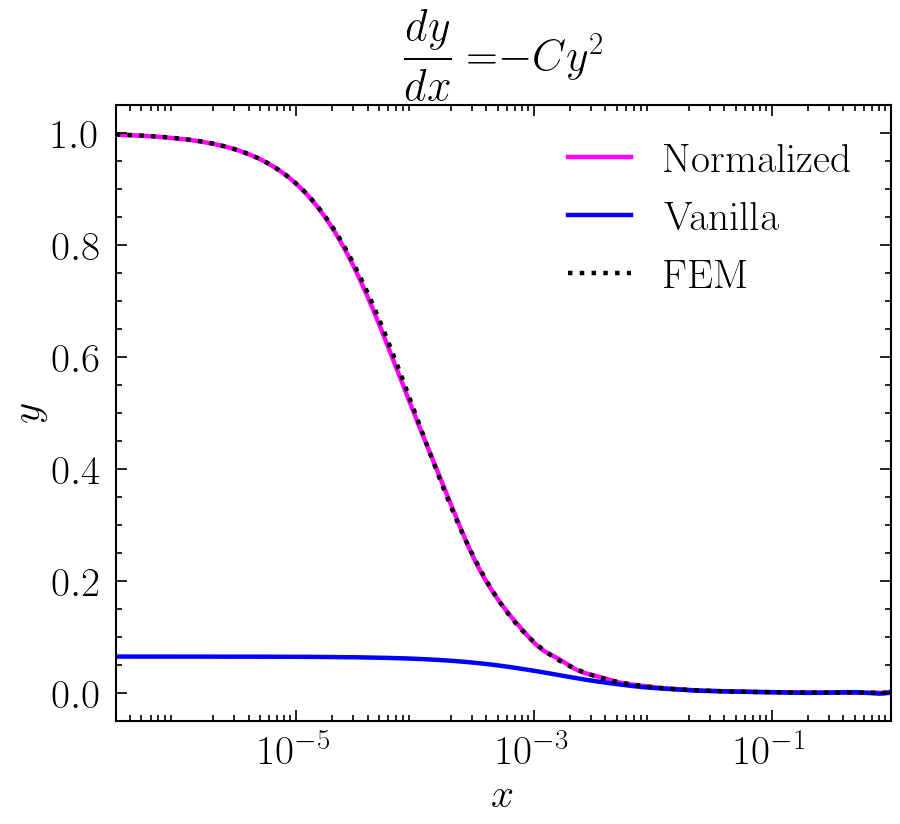

In [15]:
PINNvsFEM_fit(2, C_list, '-Cy^2')

## Benchmark on nonlinear ODEs: $\frac{dy}{dx} = C(\sin x - y)$

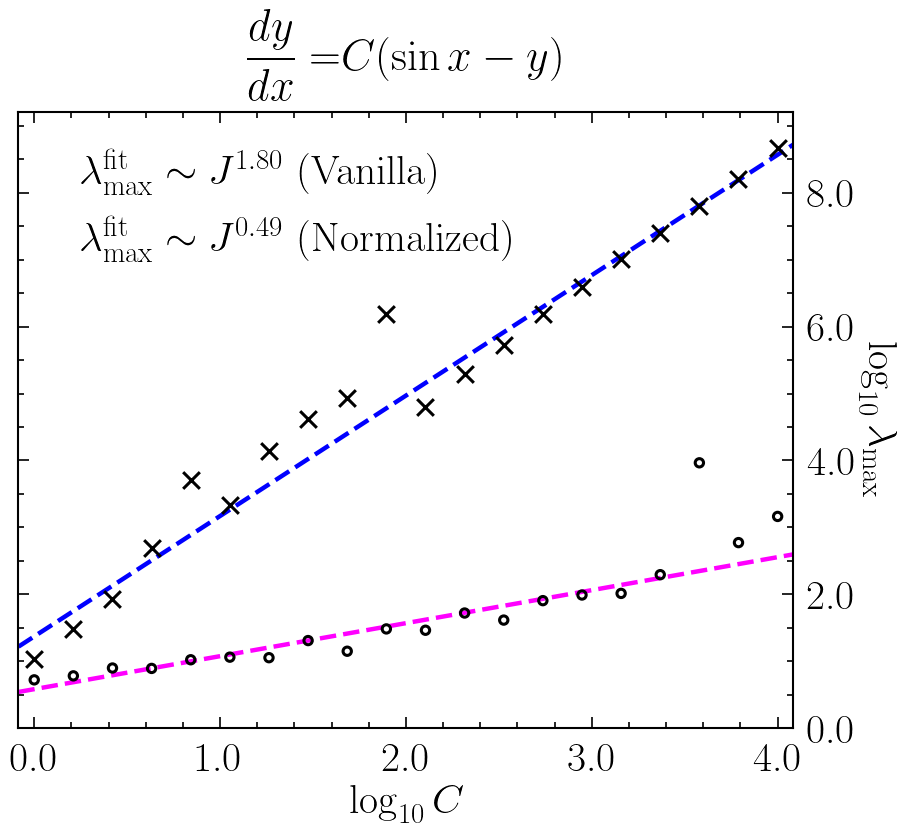

In [16]:
eig_norm = [5.29, 6.07, 7.95, 7.84, 10.56, 11.55, 11.34, 20.43, 14.16, 30.5, 29.14, 52.69, 41.33, 80.65, 97.91, 103.46, 196.91, 9229.42, 593.49, 1459.6]
eig_unnorm = [10.85, 30.75, 86.47, 499.42, 5076.17, 2129.38, 13988.94, 42195.97, 85241.23, 1525083.62, 62824.1, 194854.3, 528506.62, 1538889.5, 3900020.0, 10255556.0, 25300980.0, 63813152.0, 159210624.0, 460534752.0]

eigVSjac(3, C_list, eig_norm, eig_unnorm, r'C(\sin x - y)', Legend = False)

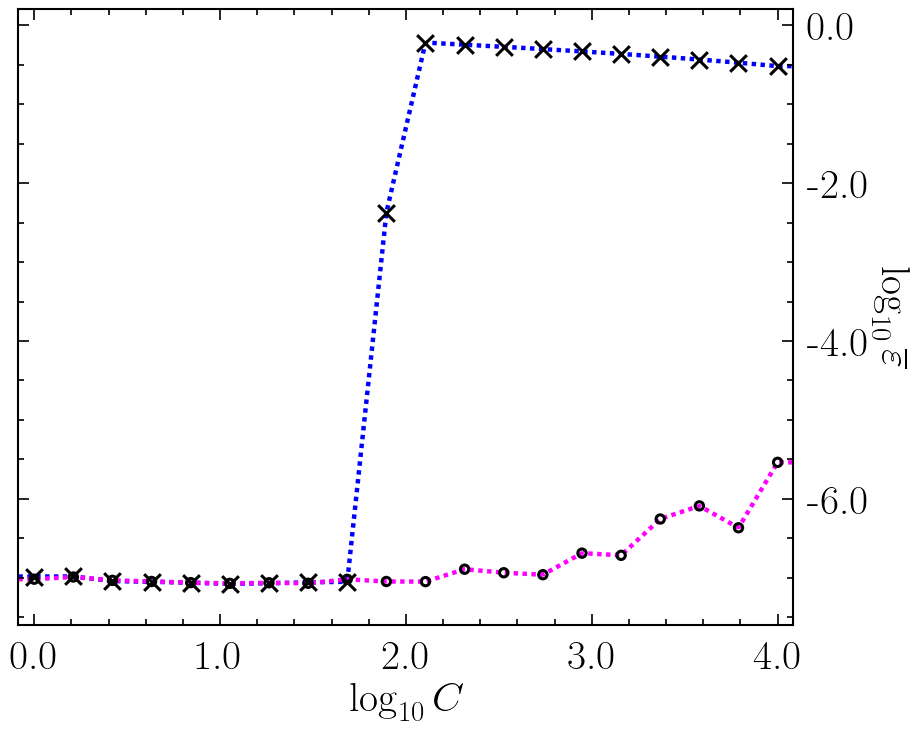

In [17]:
PINNvsFEM_diff(3, C_list, r'C(\sin x - y)')

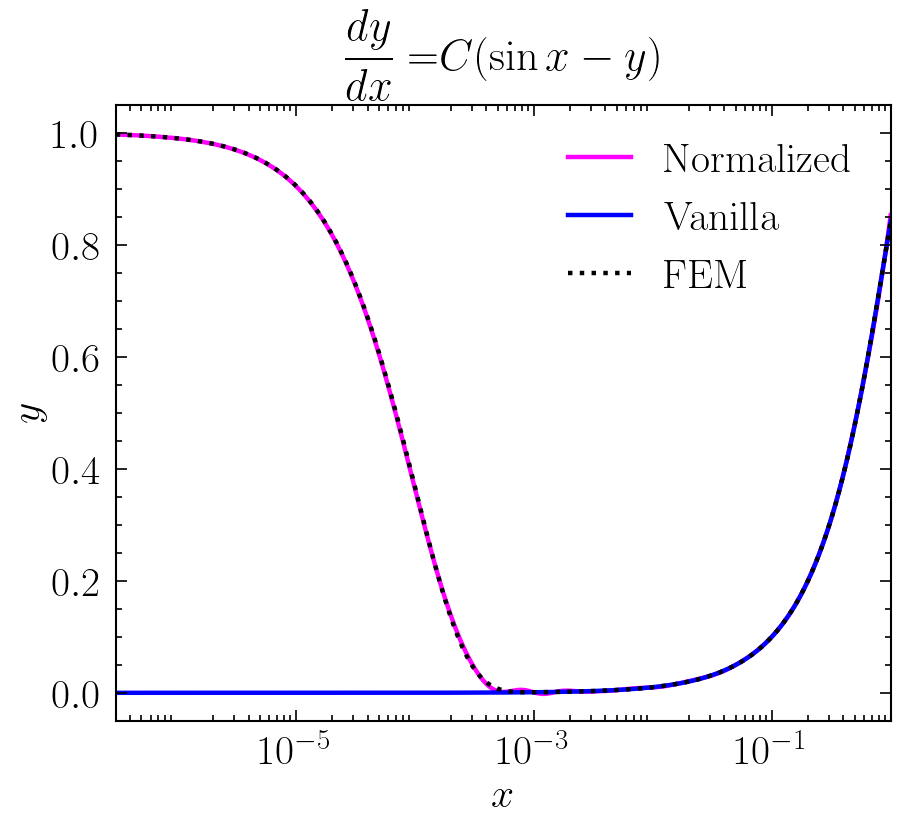

In [18]:
PINNvsFEM_fit(3, C_list, r'C(\sin x - y)')